#### Dependencies

In [21]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

##### Read in the data

In [4]:
# read in the data
hmda_all = pd.read_csv('../data/hmda_all.csv') 
hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_27236\871124796.py:3: DtypeWarning: Columns (26,27,28,29,30,31,32,33,43,44,78,80) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')


## Logistic Regression Models NO FILTER:

### Applicant Ethnicity AE

In [5]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity --> control for ae_values_2, Not Hispanic or Latino

In [11]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~
                                            ae_values_1 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14 + 
                                            income + 
                                            C(debt_to_income_ratio) + 
                                            loan_to_value_ratio +
                                            tract_minority_population_percent + 
                                            C(loan_type) + 
                                            C(applicant_age) + 
                                            gender""", 
                           data=hmda_all_nf)

In [13]:
res_ae = model_logit_ae.fit(maxiter=1000, disp=False)

In [16]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.194321
ae_values_11    0.934447
ae_values_12    0.820520
ae_values_13    0.786167
ae_values_14    0.778521
dtype: float64

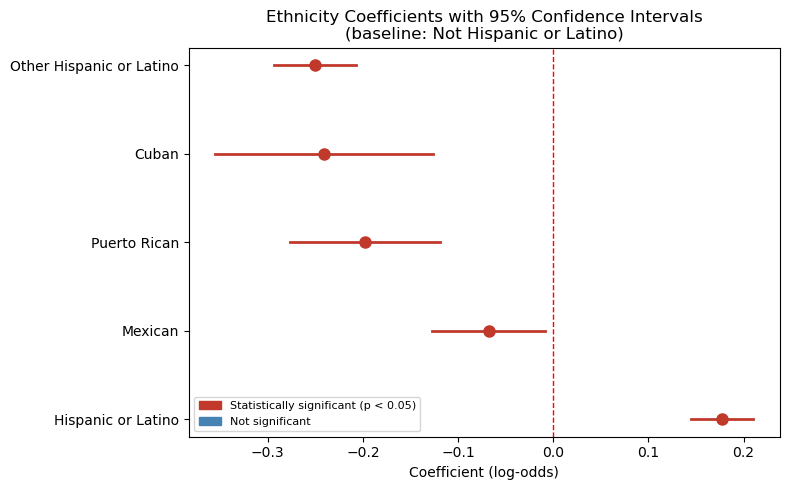

In [63]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']
coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]
pvalues = res_ae.pvalues[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs[var], i, 'o', color=color, markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch  = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
insig_patch = mpatches.Patch(color="steelblue", label="Not significant")
ax.legend(handles=[sig_patch, insig_patch], fontsize=8)

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

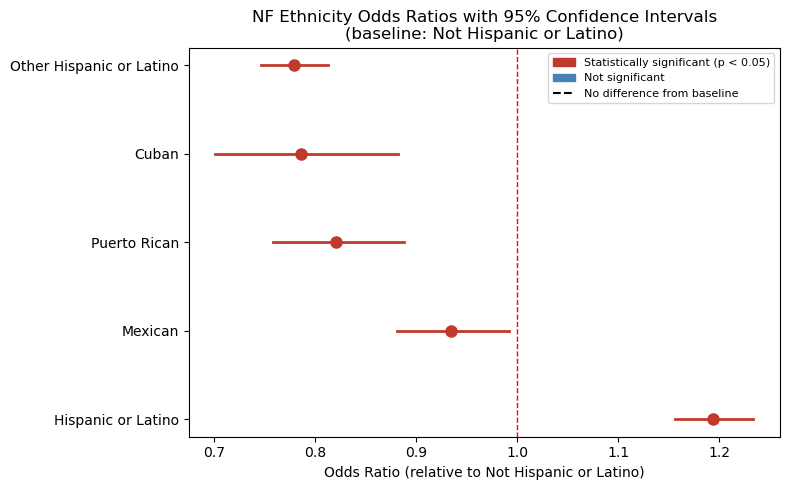

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)
pvalues = res_ae.pvalues[ethnicity_vars]

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    is_sig = pvalues[var] < 0.05
    color = "#c0392b" if is_sig else "steelblue"
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color=color, linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color=color, markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('NF Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')

sig_patch = mpatches.Patch(color="#c0392b",   label="Statistically significant (p < 0.05)")
eth_patch = mpatches.Patch(color="steelblue", label="Not significant")
no_effect = plt.Line2D([0], [0], color='black', linestyle='--', label='No difference from baseline')
ax.legend(handles=[sig_patch, eth_patch, no_effect], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig('../images/NF_App_Ethnicity_odds_ratios_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()